# Preperation of electric vehicle data

In [141]:
import pandas as pd
import numpy as np

In [142]:
days_2010 = pd.date_range(start='2010', end='2010-12-31')

Regions:

NO03 Oslo

NO11 Rogaland

NO15 Møre og Romsdal

NO18 Nordland

NO30 Viken

NO34 Innlandet

NO38 Vestfold og Telemark

NO42 Agder

NO46 Vestland

NO50 Trøndelag

NO54 Troms og Finnmark

### Number of vehicles in each zone

Read raw data

In [143]:
vehicles = pd.read_excel('Raw/total_cars_fylke_2023.xlsx', header=None, skiprows=4, nrows=11, dtype={'a':str, 'b':int}).rename(columns={0:'Fylke', 1:'Number of vehicles'}, index={1:'NO03', 5:'NO11', 7:'NO15', 9:'NO18', 0:'NO30', 2:'NO34', 3:'NO38', 4:'NO42', 6:'NO46', 8:'NO50', 10:'NO54'}).drop(columns=('Fylke')).sort_index()

In [144]:
vehicles = vehicles['Number of vehicles']
vehicles

NO03    287016
NO11    251118
NO15    152638
NO18    133764
NO30    728202
NO34    232968
NO38    236281
NO42    166009
NO46    311255
NO50    246780
NO54    129531
Name: Number of vehicles, dtype: int64

Scale number of vehicles to 2050 level

In [145]:
vehicles_2050 = (vehicles/vehicles.sum())*3247639

Round (and ensure that the total remains the same by adding +1 EV to the region which was rounded down but closest to being rounded up (NO34))

In [146]:
vehicles_2050 = vehicles_2050.round().astype(int).replace(263112, 263113)

Write to file

In [147]:
vehicles_2050.to_csv('vehicles_zones.tsv', sep = '\t', header = False)

### When cars are connected to the grid

Plug-in data

In [148]:
plug_in_weekday = [0.008, 0.003, 0.002, 0.001, 0.0, 0.001, 0.003, 0.012, 0.012, 0.008, 0.013, 0.016, 0.023, 0.029, 0.047, 0.122, 0.183, 0.086, 0.079, 0.106, 0.094, 0.069, 0.057, 0.026]
plug_in_weekend = [0.023, 0.014, 0.007, 0.007, 0.002, 0.004, 0.005, 0.005, 0.007, 0.008, 0.011, 0.023, 0.044, 0.075, 0.080, 0.117, 0.088, 0.104, 0.099, 0.089, 0.062, 0.047, 0.050, 0.029]

Create yearly plug-in data

In [149]:
plug_in = {}

for i in days_2010:
    if i.day_name() in ['Saturday', 'Sunday']:
        plug_in[i] = plug_in_weekend

    else:
        plug_in[i] = plug_in_weekday

In [150]:
plug_in = pd.DataFrame(plug_in).melt(ignore_index=False)

Plug-out data

In [151]:
plug_out_weekday = [0.003, 0.002, 0.001, 0.002, 0.0, 0.071, 0.221, 0.082, 0.048, 0.045, 0.058, 0.043, 0.033, 0.036, 0.036, 0.049, 0.084, 0.062, 0.045, 0.033, 0.024, 0.013, 0.006, 0.003]
plug_out_weekend = [0.006, 0.007, 0.002, 0.001, 0.003, 0.003, 0.067, 0.176, 0.053, 0.057, 0.061, 0.055, 0.051, 0.055, 0.049, 0.052, 0.057, 0.069, 0.057, 0.037, 0.025, 0.028, 0.018, 0.011]

Create yearly plug-out data

In [152]:
plug_out = {}

for i in days_2010:
    if i.day_name() in ['Saturday', 'Sunday']:
        plug_out[i] = plug_out_weekend

    else:
        plug_out[i] = plug_out_weekday

In [153]:
plug_out = pd.DataFrame(plug_out).melt(ignore_index=False)

Calculate the fraction of EVs connected at any hour

In [154]:
connected = pd.DataFrame({'plug_in':plug_in.reset_index().value, 'plug_out':plug_out.reset_index().value})

In [155]:
connected['change'] = connected['plug_in'] - connected['plug_out']

In [156]:
initial_connected = 0.75
result = []

for i in range(len(connected['change'])):
    if i == 0:
        result.append(initial_connected + connected['change'][i])
    else:
        result.append(result[i-1] + connected['change'][i])

In [157]:
connected['connected'] = result

Write to file

In [158]:
connected['connected'].to_csv('connected_vehicles.tsv', sep = '\t', header = False)

Plot

In [159]:
import matplotlib.pyplot as plt

In [160]:
plt.rcParams.update({'font.size': 18})

In [161]:
plot_data = connected.set_index(pd.date_range(start='2010', end='2010-12-31 23', freq='h'))
plot_data['connected_%'] = plot_data.connected*100

In [162]:
one = pd.DataFrame()

one['a'] = {'time':pd.Timestamp('2015-01-05 00:00:00'), 'value':100}
one['b'] = {'time':pd.Timestamp('2015-01-05 01:00:00'), 'value':100}
one['c'] = {'time':pd.Timestamp('2015-01-05 02:00:00'), 'value':100}
one['d'] = {'time':pd.Timestamp('2015-01-05 03:00:00'), 'value':100}
one['f'] = {'time':pd.Timestamp('2015-01-05 04:00:00'), 'value':100}
one['g'] = {'time':pd.Timestamp('2015-01-05 05:00:00'), 'value':100}
one['h'] = {'time':pd.Timestamp('2015-01-05 06:00:00'), 'value':100}
one['i'] = {'time':pd.Timestamp('2015-01-05 06:00:01'), 'value':0}
one['j'] = {'time':pd.Timestamp('2015-01-05 07:00:00'), 'value':0}
one['k'] = {'time':pd.Timestamp('2015-01-05 08:00:00'), 'value':0}
one['l'] = {'time':pd.Timestamp('2015-01-05 09:00:00'), 'value':0}
one['m'] = {'time':pd.Timestamp('2015-01-05 10:00:00'), 'value':0}
one['n'] = {'time':pd.Timestamp('2015-01-05 11:00:00'), 'value':0}
one['o'] = {'time':pd.Timestamp('2015-01-05 12:00:00'), 'value':0}
one['p'] = {'time':pd.Timestamp('2015-01-05 13:00:00'), 'value':0}
one['q'] = {'time':pd.Timestamp('2015-01-05 14:00:00'), 'value':0}
one['r'] = {'time':pd.Timestamp('2015-01-05 15:00:00'), 'value':0}
one['s'] = {'time':pd.Timestamp('2015-01-05 16:00:00'), 'value':0}
one['t'] = {'time':pd.Timestamp('2015-01-05 17:00:00'), 'value':0}
one['u'] = {'time':pd.Timestamp('2015-01-05 18:00:00'), 'value':0}
one['v'] = {'time':pd.Timestamp('2015-01-05 18:00:01'), 'value':100}
one['w'] = {'time':pd.Timestamp('2015-01-05 19:00:00'), 'value':100}
one['x'] = {'time':pd.Timestamp('2015-01-05 20:00:00'), 'value':100}
one['y'] = {'time':pd.Timestamp('2015-01-05 21:00:00'), 'value':100}
one['z'] = {'time':pd.Timestamp('2015-01-05 22:00:00'), 'value':100}
one['æ'] = {'time':pd.Timestamp('2015-01-05 23:00:00'), 'value':100}

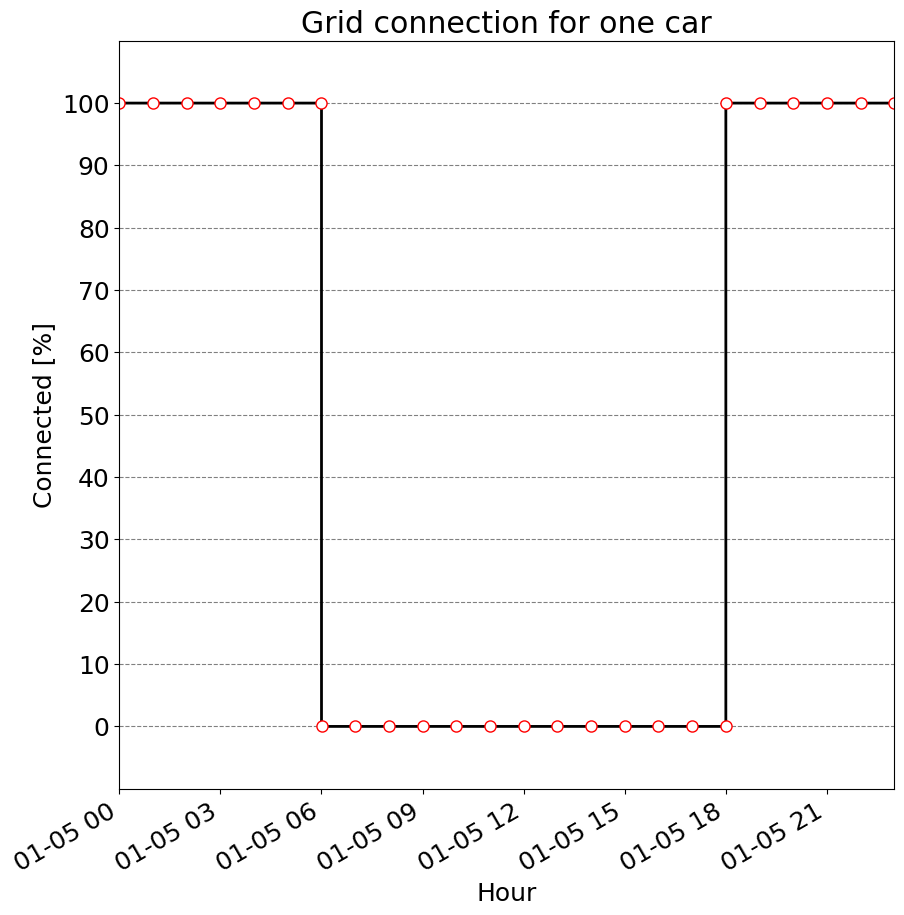

In [163]:
one.T.set_index('time').plot(figsize=(10,11), style='o-', color='black', alpha=1, markersize=8, markerfacecolor='white', linewidth=2, markeredgecolor='red', legend=None)

plt.xlabel('Hour')
plt.ylabel('Connected [%]')
plt.xlim(pd.Timestamp('2015-01-05 00:00:00'),pd.Timestamp('2015-01-05 23:00:00'))
plt.ylim([-10,110])
plt.yticks([0,10,20,30,40,50,60,70,80,90,100])
plt.grid(axis='y', color='gray', zorder=0, linestyle='--')
plt.title('Grid connection for one car')
plt.show()

In [164]:
days_2010[3] #.day_name()

Timestamp('2010-01-04 00:00:00', freq='D')

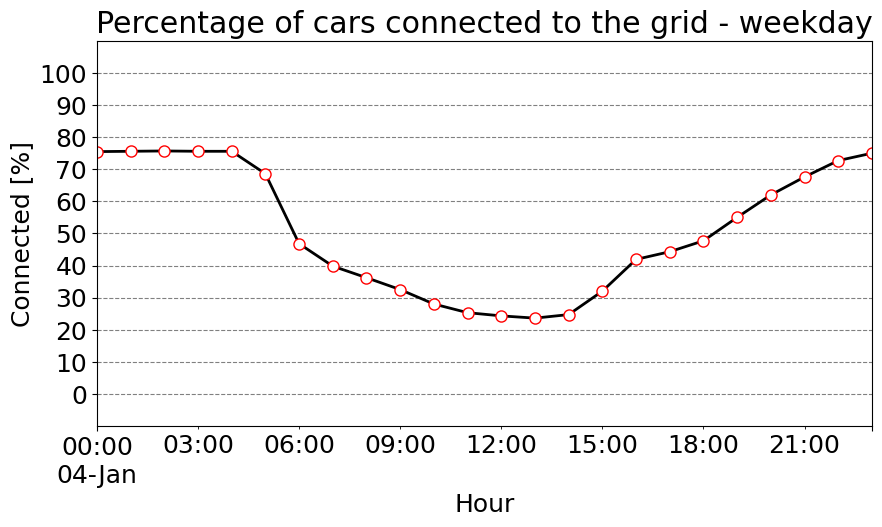

In [165]:
plot_data['connected_%']['2010-01-04'].plot(color='black', style='o-', alpha=1, figsize=(10,5), markersize=8, markerfacecolor='white', linewidth=2, markeredgecolor='red')
plt.xlabel('Hour')
plt.ylabel('Connected [%]')
plt.ylim([-10,110])
plt.yticks([0,10,20,30,40,50,60,70,80,90,100])
plt.grid(axis='y', color='gray', zorder=0, linestyle='--')
plt.title('Percentage of cars connected to the grid - weekday')
plt.show()

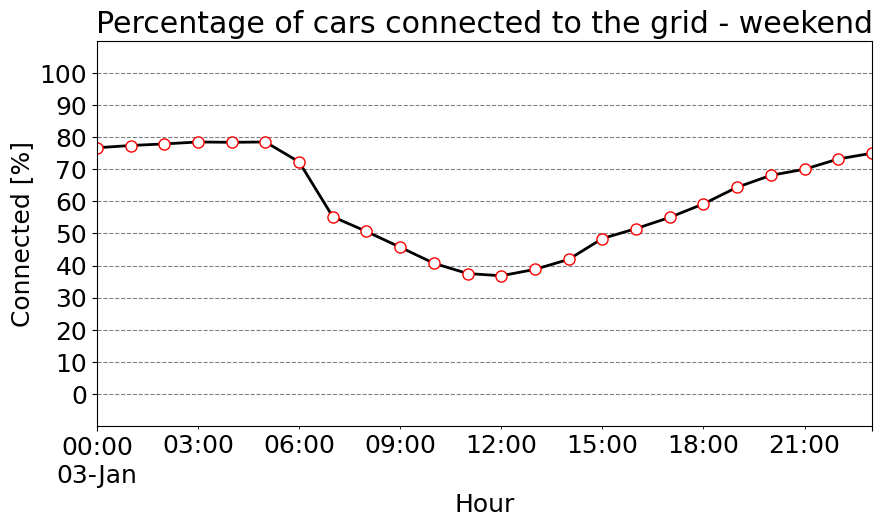

In [166]:
plot_data['connected_%']['2010-01-03'].plot(color='black', style='o-', alpha=1, figsize=(10,5), markersize=8, markerfacecolor='white', linewidth=2, markeredgecolor='red')
plt.xlabel('Hour')
plt.ylabel('Connected [%]')
plt.ylim([-10,110])
plt.yticks([0,10,20,30,40,50,60,70,80,90,100])
plt.grid(axis='y', color='gray', zorder=0, linestyle='--')
plt.title('Percentage of cars connected to the grid - weekend')
plt.show()

### Driving demand

Read raw data - driving distance per fylke

In [167]:
driving_distance = pd.read_excel('Raw/driving_distance_fylke_2023.xlsx', header=None, skiprows=5, nrows=11, dtype={'a':str, 'b':int}).rename(columns={0:'Fylke', 1:'Driving distance [10^6 km]'}, index={1:'NO03', 5:'NO11', 7:'NO15', 9:'NO18', 0:'NO30', 2:'NO34', 3:'NO38', 4:'NO42', 6:'NO46', 8:'NO50', 10:'NO54'}).drop(columns=('Fylke')).sort_index()

In [168]:
driving_distance

,Driving distance [10^6 km]
NO03,3677.7
NO11,2909.9
NO15,1781.7
NO18,1519.1
NO30,9496.8
NO34,2906.9
NO38,2906.2
NO42,2186.5
NO46,3699.3
NO50,3050.8


Calculate driving demand per vehicle

In [169]:
driving_distance['Number of vehicles'] = vehicles
driving_distance['Driving distance per car [km]'] = (driving_distance['Driving distance [10^6 km]'] / driving_distance['Number of vehicles'])*10**6
driving_distance['Daily driving distance per car [km]'] = driving_distance['Driving distance per car [km]']/365

driving_consumption = 0.00019 # [MWh/km]
driving_distance['Daily discharge per car [MWh]'] = driving_distance['Daily driving distance per car [km]']*driving_consumption

In [170]:
driving_distance

,Driving distance [10^6 km],Number of vehicles,Driving distance per car [km],Daily driving distance per car [km],Daily discharge per car [MWh]
NO03,3677.7,287016,12813.571369,35.105675,0.006670
NO11,2909.9,251118,11587.779450,31.747341,0.006032
NO15,1781.7,152638,11672.715837,31.980043,0.006076
NO18,1519.1,133764,11356.568284,31.113886,0.005912
NO30,9496.8,728202,13041.436305,35.729962,0.006789
NO34,2906.9,232968,12477.679338,34.185423,0.006495
NO38,2906.2,236281,12299.761724,33.697977,0.006403
NO42,2186.5,166009,13170.972658,36.084857,0.006856
NO46,3699.3,311255,11885.110279,32.561946,0.006187
NO50,3050.8,246780,12362.428074,33.869666,0.006435


In [171]:
demand_driving_hourly = pd.DataFrame(((1-connected['connected'])/((1-connected['connected']).sum()))*len(days_2010)).rename(columns={'connected':0}).dot(pd.DataFrame(driving_distance['Daily discharge per car [MWh]']).rename(columns={'Daily discharge per car [MWh]':0}).T)

In [172]:
demand_driving_hourly

,NO03,NO11,NO15,NO18,NO30,NO34,NO38,NO42,NO46,NO50,NO54
0,0.000147,0.000133,0.000134,0.000131,0.000150,0.000143,0.000141,0.000151,0.000137,0.000142,0.000136
1,0.000147,0.000133,0.000134,0.000130,0.000149,0.000143,0.000141,0.000151,0.000136,0.000141,0.000135
2,0.000146,0.000132,0.000133,0.000129,0.000149,0.000142,0.000140,0.000150,0.000135,0.000141,0.000135
3,0.000147,0.000133,0.000134,0.000130,0.000149,0.000143,0.000141,0.000151,0.000136,0.000141,0.000135
4,0.000147,0.000133,0.000134,0.000130,0.000149,0.000143,0.000141,0.000151,0.000136,0.000141,0.000135
...,...,...,...,...,...,...,...,...,...,...,...
8755,0.000270,0.000245,0.000246,0.000240,0.000275,0.000263,0.000260,0.000278,0.000251,0.000261,0.000249
8756,0.000228,0.000207,0.000208,0.000202,0.000232,0.000222,0.000219,0.000235,0.000212,0.000220,0.000210
8757,0.000195,0.000176,0.000177,0.000173,0.000198,0.000190,0.000187,0.000200,0.000181,0.000188,0.000179
8758,0.000164,0.000148,0.000149,0.000145,0.000167,0.000160,0.000158,0.000169,0.000152,0.000158,0.000151


<AxesSubplot: >

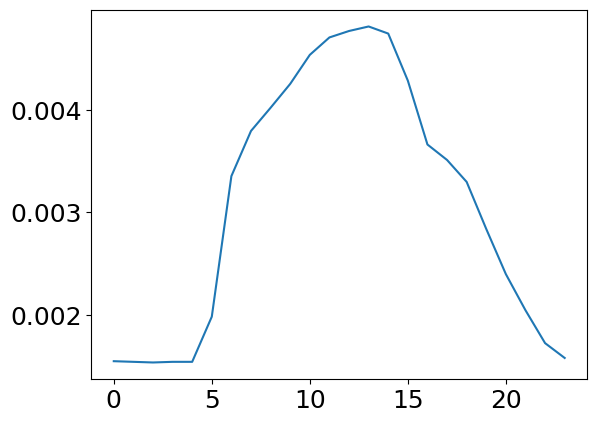

In [173]:
demand_driving_hourly.sum(axis=1)[:24].plot()

<AxesSubplot: >

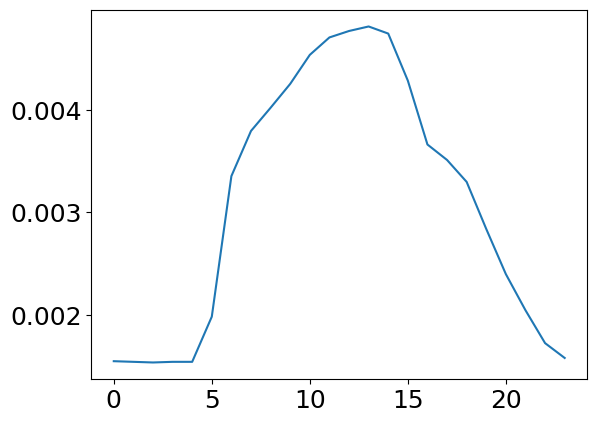

In [174]:
demand_driving_hourly.sum(axis=1)[:24].plot()

In [175]:
hourly_driving_demand = demand_driving_hourly.melt(ignore_index=False)

In [176]:
hourly_driving_demand.sum()[1]*3247639

82979086.41770783

Write to file

In [177]:
pd.Series(hourly_driving_demand.value).set_axis((hourly_driving_demand.index).astype(str) + '.' + hourly_driving_demand.variable).to_csv('demand_driving_MWh.tsv', sep = '\t', header = False)

### Static EV charging

Calculate the static EV charging demand for weekdays, saturdays and sundays

In [178]:
total_yearly_demand = demand_driving_hourly.dot(pd.DataFrame(vehicles).rename(columns={'Number of vehicles':0})).sum()/vehicles.sum() #per car

In [179]:
total_weekly_demand = total_yearly_demand/(365/7)

In [180]:
# read raw load curves

load_curve_weekday = pd.read_csv('Raw/ev_load_curve_weekday.tsv', sep='\t', header=None, index_col=0)
load_curve_saturday = pd.read_csv('Raw/ev_load_curve_saturday.tsv', sep='\t', header=None, index_col=0)
load_curve_sunday = pd.read_csv('Raw/ev_load_curve_sunday.tsv', sep='\t', header=None, index_col=0)

In [181]:
# Calculate each load curve's share of the total weekly load

total = 5*load_curve_weekday.sum().iloc[0] + load_curve_saturday.sum().iloc[0] + load_curve_sunday.sum().iloc[0]

weekday_weekly_fraction = (load_curve_weekday.sum().iloc[0])/total
saturday_weekly_fraction = (load_curve_saturday.sum().iloc[0])/total
sunday_weekly_fraction = (load_curve_sunday.sum().iloc[0])/total

In [182]:
weekday_weekly_fraction

0.1420271603731847

In [183]:
saturday_weekly_fraction

0.1469935058481462

In [184]:
sunday_weekly_fraction

0.14287069228593027

In [185]:
# normalise the load profiles and then scale with each days share of the demand

weekday_demand = (load_curve_weekday/load_curve_weekday.sum())*weekday_weekly_fraction*total_weekly_demand[0]
saturday_demand = (load_curve_saturday/load_curve_saturday.sum())*saturday_weekly_fraction*total_weekly_demand[0]
sunday_demand = (load_curve_weekday/load_curve_weekday.sum())*sunday_weekly_fraction*total_weekly_demand[0]

Create yearly series

In [186]:
data_dict = {}

for i in days_2010:
    if i.day_name() == 'Saturday':
        data_dict[i] = saturday_demand.values.T[0]

    elif i.day_name() == 'Sunday':
        data_dict[i] = sunday_demand.values.T[0]
    
    else:
        data_dict[i] = weekday_demand.values.T[0]
        

In [187]:
demand = pd.DataFrame(data_dict).melt(ignore_index=False).reset_index().value

In [188]:
demand

0       0.000408
1       0.000282
2       0.000187
3       0.000127
4       0.000083
          ...   
8755    0.000546
8756    0.000576
8757    0.000567
8758    0.000538
8759    0.000467
Name: value, Length: 8760, dtype: float64

Write to file

In [189]:
demand.to_csv('demand_ev_charging_MWh.tsv', sep = '\t', header = False)

### Total EV charging demand

In [190]:
(demand*(vehicles.sum())).sum()

6776147.139148772

In [191]:
demand_driving_hourly.dot(pd.DataFrame(vehicles).rename(columns={'Number of vehicles':0})).sum()[0]

6776254.999999999